# Ejercicio 2

Gonzalo Cano Padilla

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

ticker = "SPY"
inicio = "2020-01-01"
fin = "2026-03-03"

monto_total = 5000
aporte_dca = 100
n_semanas = 75
n_sim = 10000

precios = yf.download(ticker, start=inicio, end=fin, auto_adjust=True)["Close"]
precios.dropna(inplace=True)
precios

[*********************100%***********************]  1 of 1 completed


Ticker,SPY
Date,
2020-01-02,297.699005
2020-01-03,295.444702
2020-01-06,296.571899
2020-01-07,295.738037
2020-01-08,297.314117
...,...
2026-02-24,687.349976
2026-02-25,693.150024
2026-02-26,689.299988


In [4]:
precios_semana = precios.resample("W").last()

rendimientos = precios_semana.pct_change().dropna()

media_semanal = rendimientos.mean().item()
std_semanal   = rendimientos.std().item()
precio_actual = precios_semana.iloc[-1].item()

print(f"Rendimiento semanal promedio : {media_semanal:.4%}")
print(f"Desviación estándar semanal  : {std_semanal:.4%}")
print(f"Precio actual de SPY         : ${precio_actual:.2f}")
print(f"\nAportes DCA: {n_semanas} semanas × ${aporte_dca} = ${n_semanas * aporte_dca:,}")
print(f"Inversión única              : ${monto_total:,}")

Rendimiento semanal promedio : 0.2982%
Desviación estándar semanal  : 2.6789%
Precio actual de SPY         : $686.38

Aportes DCA: 75 semanas × $100 = $7,500
Inversión única              : $5,000


In [5]:
precios_sim = np.zeros((n_semanas + 1, n_sim))
precios_sim[0] = precio_actual

for t in range(1, n_semanas + 1):
    # Rendimiento aleatorio de esta semana (distribución normal)
    r = np.random.normal(media_semanal, std_semanal, n_sim)
    precios_sim[t] = precios_sim[t - 1] * (1 + r)

print(f"Simulación: {n_sim:,} trayectorias × {n_semanas} semanas")
print(f"Precio mínimo simulado al final : ${precios_sim[-1].min():.2f}")
print(f"Precio máximo simulado al final : ${precios_sim[-1].max():.2f}")
print(f"Precio promedio simulado al final: ${precios_sim[-1].mean():.2f}")

Simulación: 10,000 trayectorias × 75 semanas
Precio mínimo simulado al final : $378.92
Precio máximo simulado al final : $1906.61
Precio promedio simulado al final: $859.03


In [6]:
acciones_unica = monto_total / precio_actual
valor_unica = acciones_unica * precios_sim[-1]
valor_dca = np.zeros(n_sim)
monto_dca = aporte_dca * n_semanas

for semana in range(n_semanas):
    precio_semana = precios_sim[semana]
    acciones_compradas = aporte_dca / precio_semana
    valor_dca += acciones_compradas * precios_sim[-1]

print("=" * 50)
print("INVERSIÓN ÚNICA")
print(f"  Valor final promedio : ${valor_unica.mean():,.2f}")
print(f"  Desviación estándar  : ${valor_unica.std():,.2f}")
print(f"  Prob. de pérdida     : {(valor_unica < monto_total).mean():.2%}")

print("\nDCA — INVERSIÓN PERIÓDICA")
print(f"  Valor final promedio : ${valor_dca.mean():,.2f}")
print(f"  Desviación estándar  : ${valor_dca.std():,.2f}")
print(f"  Prob. de pérdida     : {(valor_dca < monto_dca).mean():.2%}")

INVERSIÓN ÚNICA
  Valor final promedio : $6,257.67
  Desviación estándar  : $1,471.70
  Prob. de pérdida     : 19.78%

DCA — INVERSIÓN PERIÓDICA
  Valor final promedio : $8,431.61
  Desviación estándar  : $1,186.99
  Prob. de pérdida     : 22.73%


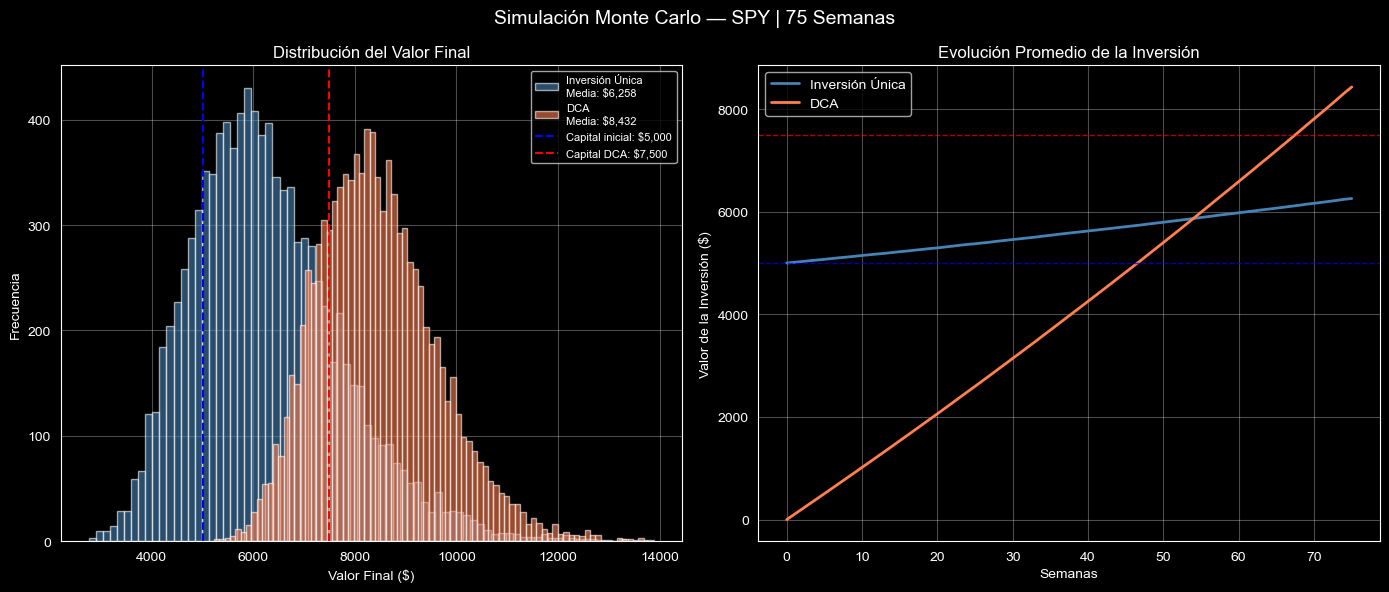

In [7]:
# ============================================================
# PASO 5: Gráficas
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Simulación Monte Carlo — SPY | 75 Semanas", fontsize=14)

# --- GRÁFICA 1: Histogramas comparativos ---
ax1 = axes[0]
ax1.hist(valor_unica, bins=80, alpha=0.6, color="steelblue",
         label=f"Inversión Única\nMedia: ${valor_unica.mean():,.0f}")
ax1.hist(valor_dca,   bins=80, alpha=0.6, color="coral",
         label=f"DCA\nMedia: ${valor_dca.mean():,.0f}")
ax1.axvline(monto_total, color="blue",  linestyle="--", linewidth=1.5, label=f"Capital inicial: ${monto_total:,}")
ax1.axvline(monto_dca,   color="red",   linestyle="--", linewidth=1.5, label=f"Capital DCA: ${monto_dca:,}")
ax1.set_xlabel("Valor Final ($)")
ax1.set_ylabel("Frecuencia")
ax1.set_title("Distribución del Valor Final")
ax1.legend(fontsize=8)
ax1.grid(alpha=0.3)

# --- GRÁFICA 2: Evolución promedio semana a semana ---
ax2 = axes[1]

evol_unica = acciones_unica * precios_sim.mean(axis=1)

evol_dca = np.zeros(n_semanas + 1)
for semana in range(n_semanas):
    acciones_hasta_ahora = sum(
        aporte_dca / precios_sim[s].mean() for s in range(semana + 1)
    )
    evol_dca[semana + 1] = acciones_hasta_ahora * precios_sim[semana + 1].mean()

semanas = np.arange(n_semanas + 1)
ax2.plot(semanas, evol_unica, color="steelblue", linewidth=2, label="Inversión Única")
ax2.plot(semanas, evol_dca,   color="coral",     linewidth=2, label="DCA")
ax2.axhline(monto_total, color="blue", linestyle="--", linewidth=1, alpha=0.7)
ax2.axhline(monto_dca,   color="red",  linestyle="--", linewidth=1, alpha=0.7)
ax2.set_xlabel("Semanas")
ax2.set_ylabel("Valor de la Inversión ($)")
ax2.set_title("Evolución Promedio de la Inversión")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("dca_vs_unica.png", dpi=150)
plt.show()

## Análisis: DCA vs Inversión Única


| Estrategia       | Capital Invertido | Valor Final Promedio | Desv. Estándar | Prob. de Pérdida |
|------------------|-------------------|----------------------|----------------|------------------|
| Inversión Única  | $5,000            | $6,257.67            | $1,471.70      | 19.78%           |
| DCA (75 semanas) | $7,500            | $8,431.61            | $1,186.99      | 22.73%           |

El DCA genera un valor final promedio mayor (8,431 vs 6,257), pero esto se
explica principalmente porque **invierte más capital en total** (7,500 vs 5,000).
En términos de rendimiento sobre lo invertido, la inversión única es más eficiente:
genera un 25.2% de ganancia vs 12.4% del DCA.

La inversión única también presenta **menor probabilidad de pérdida** (19.78% vs
22.73%) y mayor volatilidad (1,471 vs 1,186), lo que refleja que al exponer
todo el capital desde el inicio, los resultados son más dispersos.

### ¿Cuándo es mejor cada estrategia?

**DCA:** es mejor cuando no se dispone del capital completo desde el inicio,
o cuando el mercado es muy volátil, ya que reduce el riesgo de invertir todo
en un mal momento.

**Inversión única:** es más ventajosa en mercados con tendencia alcista sostenida
(como SPY históricamente), ya que el capital trabaja desde el primer día y
genera mayor rendimiento sobre lo invertido.